## Object creation example

In this notebook, an exaple for creating an object with a F-GRIN will be given. First I define the modules:

In [ ]:
import torch
import matplotlib.pyplot as plt
import imageio
import io
from IPython.display import Image, display
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}.")


Running on cuda.


tensor([0])

Now I create the functions for visualization:

In [ ]:
def show_z_scan_gif(volume: torch.Tensor, 
                    cmap: str = 'gray', 
                    duration: float = 0.1, 
                    pix_size: float = 1e-6):
    """
    Displays a loop showing all the slices of a volumetric object.

    Args:
        volume (_type_): _description_
        cmap (str, optional): _description_. Defaults to 'gray'.
        duration (float, optional): _description_. Defaults to 0.1.
        pix_size (_type_, optional): _description_. Defaults to None.
    """

    volume = volume.cpu().numpy()
    D = volume.shape[0]
    frames = []

    vmin = np.min(volume)
    vmax = np.max(volume)

    for z in range(D):
        fig, ax = plt.subplots(figsize=(4, 4), dpi=80)
        ax.imshow(volume[z], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis('off')

        z_pos = (z - D / 2) * pix_size * 1e6
        label = f"Z = {z_pos:.2f} µm"

        ax.text(0.05, 0.95, label, transform=ax.transAxes,
                fontsize=10, color='white', ha='left', va='top',
                bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))

        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        frames.append(imageio.v3.imread(buf))
        buf.close()

    # Create looping GIF
    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, frames, format='gif', duration=duration, loop=0)
    gif_bytes.seek(0)

    display(Image(data=gif_bytes.read(), format='gif'))

I define the F-GRIN sample as shown by the article writen by David H Lippman et al. named [Freeform gradient-index media: a new frontier in freeform optics](https://pubmed-ncbi-nlm-nih-gov.tudelft.idm.oclc.org/34809097/):

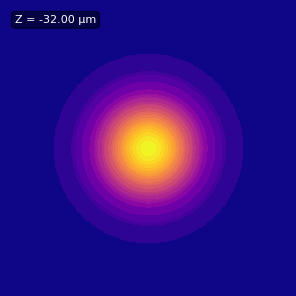

In [ ]:
pix_size = 1e-6
D, H, W = (64,256,256)

Z, Y, X = torch.meshgrid(
    pix_size*(torch.arange(D, device=device) - D/2),
    pix_size*(torch.arange(H, device=device) - H/2),
    pix_size*(torch.arange(W, device=device) - W/2),
    indexing='ij'
)

λ = 535e-9
z0 = 0.0
w0 = 30e-6  # beam waist

sample_3D = torch.exp(-(X**2 + Y**2) / (w0**2 + (Z - z0)**2))
sample_3D -= sample_3D.min()
sample_3D /= sample_3D.max()

show_z_scan_gif(sample_3D, cmap='plasma', duration=0.1, pix_size=pix_size)